In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
from matplotlib.colors import Normalize
from matplotlib.colors import LinearSegmentedColormap

In [2]:
# Parameters
N = 200
relaxation = 0.95
tol = 1e-6

In [3]:
def grid(N):
  """
  Creates grid of points N x N divisions.
  Returns x, y, X, Y, and grid spacing dx.
  """
  # Create grid points
  x = np.linspace(-1.0, 1.0, N)
  y = np.linspace(-1.0, 1.0, N)
  X, Y = np.meshgrid(x, y)
  dx = x[1] - x[0]

  return x, y, X, Y, dx

In [4]:
def capacitor(N, iy_lo, iy_hi, ix_neg, ix_pos):
  """
  Initialise potential and fixed-point arrays for a capacitor.
  Returns the potential array V and a boolean array fixed indicating which points are fixed.
  """
  # Create grid
  V = np.zeros((N, N))

  # Mark fixed points
  fixed = np.zeros((N, N), dtype=bool)

  # Assign potentials and fixed points for the plates
  V[iy_lo:iy_hi+1, ix_pos] = 1.0; fixed[iy_lo:iy_hi+1, ix_pos] = True
  V[iy_lo:iy_hi+1, ix_neg] = -1.0; fixed[iy_lo:iy_hi+1, ix_neg] = True

  return V, fixed

In [5]:
def potential(V, fixed):
  """
    Solves Laplace's equation with successive relaxation using the finite difference method:
    V[i,j] = 0.25 * (V[i-1, j] + V[i+1, j] + V[i, j-1] + V[i, j+1])
    The potential is updated iteratively until convergence is reached, which is determined by
    the maximum change in potential (dV) being less than a specified tolerance (tol).
    Returns the converged potential distribution V.
  """
  # Run until convergence is reached
  while True:
        V_new = 0.25 *(V[:-2, 1:-1] + V[2:, 1:-1] + V[1:-1, :-2] + V[1:-1, 2:])
        dV = relaxation * (V_new - V[1:-1, 1:-1])
        dV[fixed[1:-1, 1:-1]] = 0.0
        if np.max(np.abs(dV)) < tol:
            break
        V[1:-1, 1:-1] += dV
        
  return V

In [6]:
def E_field(V, dx):
  """
    Computes the electric field components (Ex, Ey) and magnitude (E_mag) from the
    potential distribution V. The electric field is calculated using the negative gradient 
    of the potential: Ex = -dV/dx, Ey = -dV/dy
    Returns the electric field components Ex, Ey and magnitude E_mag.
  """
  Ey, Ex = np.gradient(-V, dx)
  E_mag = np.sqrt(Ex**2 + Ey**2)
  return Ex, Ey, E_mag

In [7]:
def solve(N, plate_half_len=0.4, plate_sep=0.2):

    # Create grid
    x, y, X, Y, dx = grid(N)
    
    # Determine plate positions in grid indices
    ix_pos = int(round(( plate_sep + 1.0) / dx))
    ix_neg = int(round((-plate_sep  + 1.0) / dx))
    iy_lo  = int(round((-plate_half_len + 1.0) / dx))
    iy_hi  = int(round(( plate_half_len + 1.0) / dx))
    ix_pos = np.clip(ix_pos, 1, N - 2)
    ix_neg = np.clip(ix_neg, 1, N - 2)
    iy_lo  = np.clip(iy_lo,  0, N - 1)
    iy_hi  = np.clip(iy_hi,  0, N - 1)

    # Initialize potential and fixed points for the capacitor
    V, fixed = capacitor(N, iy_lo, iy_hi, ix_neg, ix_pos)
    V = potential(V, fixed)

    # Compute electric field components and magnitude
    Ex, Ey, E_mag = E_field(V, dx)
    E_max = np.max(E_mag)
    Ex, Ey, E_mag = Ex / E_max, Ey / E_max, E_mag / E_max

    return x, y, X, Y, V, Ex, Ey, E_mag, ix_pos, ix_neg, iy_lo, iy_hi

In [8]:
def draw_plates(ax, x, y, ixp, ixn, iy0, iy1, lw=2.5):
    """   
      Draws the capacitor plates on the plot as black lines.
    """
    ax.plot([x[ixp]] * 2, [y[iy0], y[iy1]], "r-", lw=lw, solid_capstyle="butt")
    ax.plot([x[ixn]] * 2, [y[iy0], y[iy1]], "b-", lw=lw, solid_capstyle="butt")

In [9]:
def quiver_normalize(X, Y, Ex, Ey, E_mag, step):
    """
    Return normalised quiver arrays through subsampling to remove clutter. normalizes the 
    electric field components and their magnitudes by a specified step size. Normalizes 
    the electric field components to unit vectors for quiver plotting. 
    Returns the normalized grid points (xq, yq), normalized electric field components (Exh, Eyh),
    and magnitudes (Eq).
    """

    # normalize the grid and electric field components
    xq = X[::step, ::step]
    yq = Y[::step, ::step]
    Exq = Ex[::step, ::step]
    Eyq = Ey[::step, ::step]
    Eq = E_mag[::step, ::step]

    # Normalize the electric field components to unit vectors, handling zero magnitudes to avoid division by zero
    # while also preventing error messages from being sent.
    with np.errstate(invalid="ignore", divide="ignore"):
        Exh = np.where(Eq > 0, Exq / Eq, 0.0)
        Eyh = np.where(Eq > 0, Eyq / Eq, 0.0)
        
    return xq, yq, Exh, Eyh, Eq

In [10]:
"Create grid and solve for potential and electric field"

x, y, X, Y, V, Ex, Ey, E_mag, ixp, ixn, iy0, iy1 = solve(N)

xq, yq, Exh, Eyh, Eq = quiver_normalize(X, Y, Ex, Ey, E_mag, step=12)

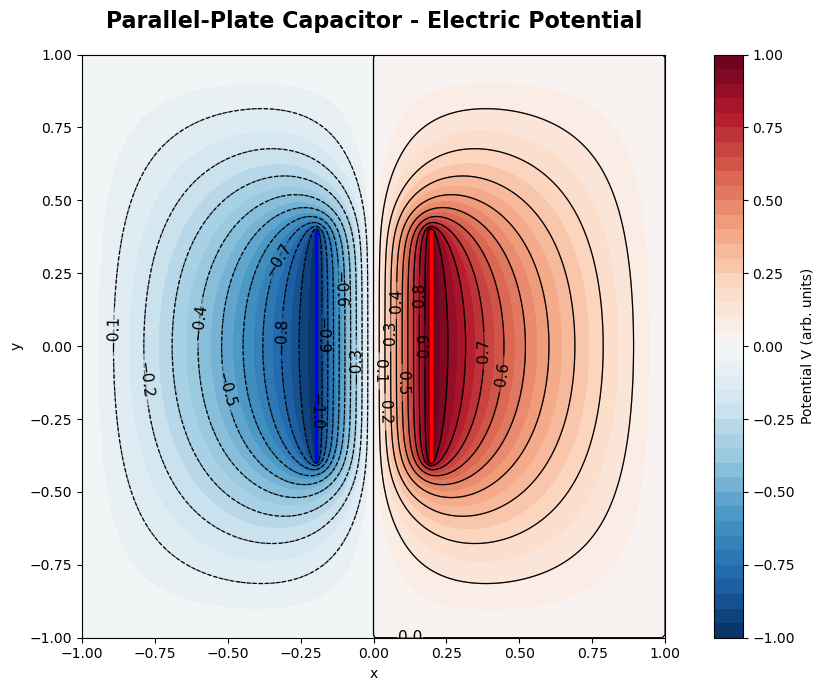

In [11]:
"Potential Contour Plot"

fig1, ax = plt.subplots(figsize=(10, 7), dpi=100, facecolor="white")
fig1.suptitle("Parallel-Plate Capacitor - Electric Potential", fontsize=16, fontweight="semibold")

cf = ax.contourf(X, Y, V, levels=40, cmap="RdBu_r")
cs = ax.contour(X, Y, V, levels=20, colors="k", linewidths=0.8)
ax.clabel(cs, cs.levels[::1], fontsize=11, inline=True, colors="black")
ax.contour(X, Y, V, levels=20, colors="k", linewidths=1, alpha=0.45)
fig1.colorbar(cf, ax=ax, label="Potential V (arb. units)")
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.set_aspect("equal")
draw_plates(ax, x, y, ixp, ixn, iy0, iy1)
ax.set_xlim(-1, 1); ax.set_ylim(-1, 1)

fig1.tight_layout()

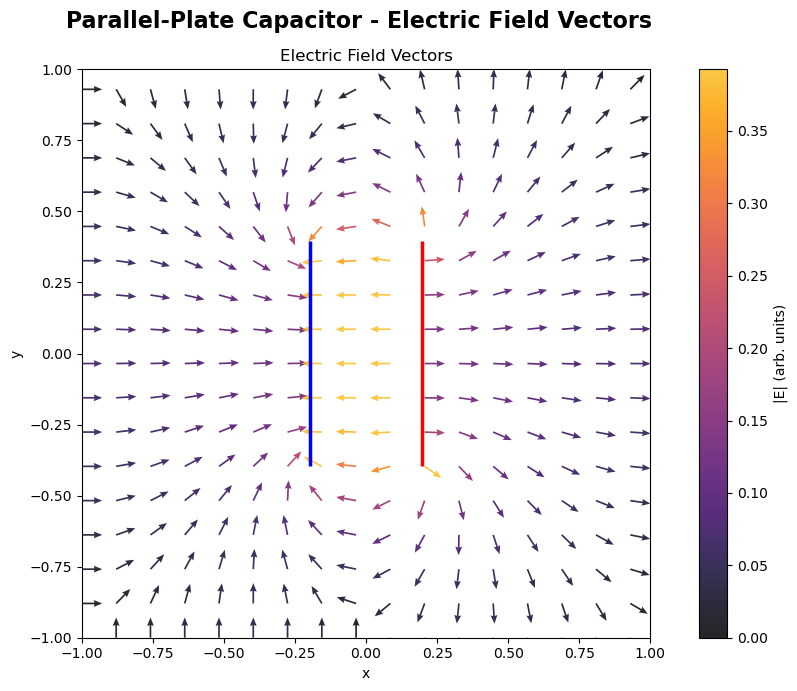

In [12]:
inferno_dark = LinearSegmentedColormap.from_list(
    "inferno_dark", plt.cm.inferno(np.linspace(0, 0.85, 256)))

fig2, ax = plt.subplots(figsize=(10, 7), dpi=100, facecolor="white")
fig2.suptitle("Parallel-Plate Capacitor - Electric Field Vectors", fontsize=16, fontweight="semibold")

vmax1 = float(np.percentile(Eq[Eq > 0], 95))
norm1 = Normalize(vmin=0, vmax=vmax1)
qv = ax.quiver(xq, yq, Exh, Eyh, Eq,
               cmap=inferno_dark, norm=norm1,
               angles="xy", scale=28, width=0.003,
               headwidth=4, headlength=5, alpha=0.85)
fig2.colorbar(qv, ax=ax, label="|E| (arb. units)")
ax.set_title("Electric Field Vectors")
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.set_aspect("equal")
draw_plates(ax, x, y, ixp, ixn, iy0, iy1)
ax.set_xlim(-1, 1); ax.set_ylim(-1, 1)

fig2.tight_layout()

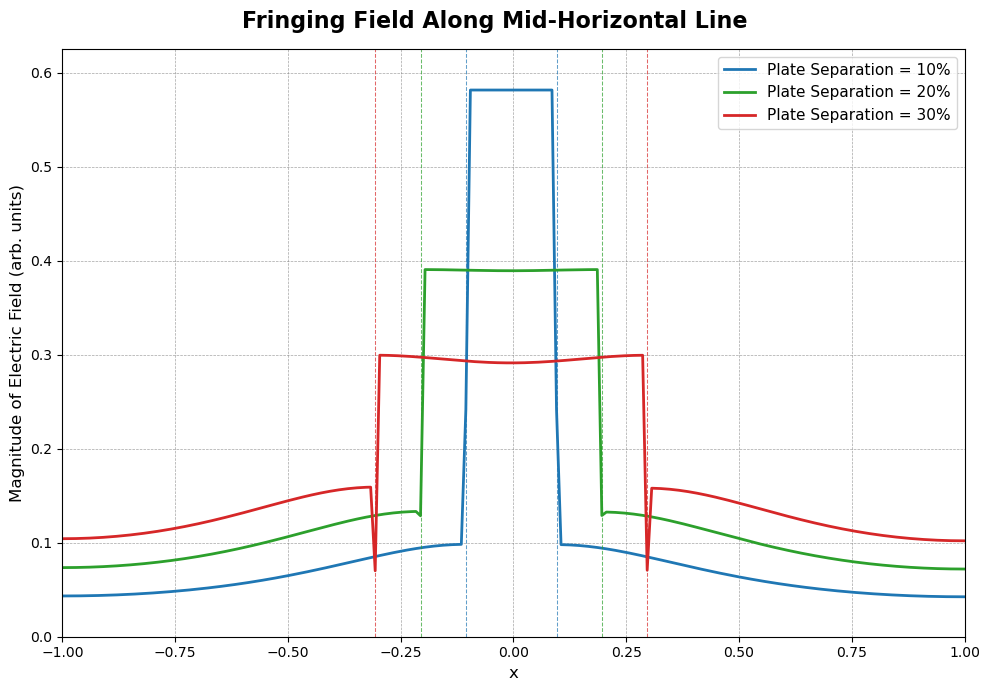

In [13]:
"Fringing Field Along Mid-Horizontal Line"

seps = [20, 40, 60]   # Plate separation in grid units
colors = ["#1f77b4", "#2ca02c",  "#d62728"]
labels = [f"Plate Separation = {int(s / N * 100)}%" for s in seps]
mid_row = N // 2

fig3, ax = plt.subplots(figsize=(10, 7), dpi=100, facecolor="white")

for sep, color, label in zip(seps, colors, labels):
    # Convert grid-unit half-separation to physical coordinate
    plate_sep = (sep / 2) / (N - 1) * 2
    xi, yi, _, _, _, _, _, Ei, ixpi, ixni, _, _ = solve(N, plate_half_len=0.4, plate_sep=plate_sep)
    x_pos= np.linspace(-1, 1, N)
    ax.plot(x_pos, Ei[mid_row, :], color=color, lw=2, label=label)
    ax.axvline(xi[ixni], color=color, lw=0.75, ls="--", alpha=0.7)
    ax.axvline(xi[ixpi], color=color, lw=0.75, ls="--", alpha=0.7)

fig3.suptitle("Fringing Field Along Mid-Horizontal Line", fontsize=16, fontweight="semibold")
ax.set_xlabel("x", fontsize=12)
ax.set_ylabel("Magnitude of Electric Field (arb. units)", fontsize=12)
ax.legend(fontsize=11, frameon=True, loc="upper right")
ax.set_xlim(-1, 1)
ax.set_ylim(bottom=0, top=0.625)
ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.7, color="gray")
fig3.tight_layout()

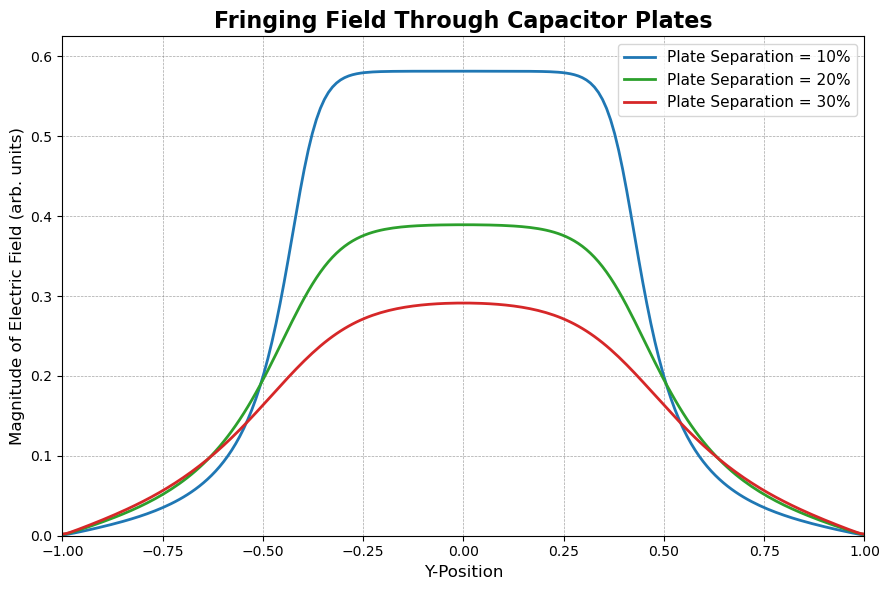

In [14]:
"Fringing Field Through Capacitor Plates"

fig4, ax = plt.subplots(figsize=(9, 6), dpi=100, facecolor="white")

for sep, color, label in zip(seps, colors, labels):
    plate_sep = (sep / 2) / (N - 1) * 2
    xi, yi, _, _, _, _, _, Ei, ixpi, ixni, iy0i, iy1i = solve(N, plate_half_len=0.4, plate_sep=plate_sep)
    ax.plot(yi, Ei[:, N // 2], color=color, lw=2, label=label)

ax.set_title("Fringing Field Through Capacitor Plates", fontsize=16, fontweight="semibold")
ax.set_xlabel("Y-Position", fontsize=12)
ax.set_ylabel("Magnitude of Electric Field (arb. units)", fontsize=12)
ax.legend(fontsize=11, frameon=True, loc="upper right")
ax.set_xlim(-1, 1)
ax.set_ylim(bottom=0, top=0.625)
ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.7, color="gray")
fig4.tight_layout()